In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import copy
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Datathon/Analytical/sales.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

def add_features(frame):
    f = frame.copy()
    f['dayofweek_sin'] = np.sin(2 * np.pi * f['Date'].dt.dayofweek / 7)
    f['dayofweek_cos'] = np.cos(2 * np.pi * f['Date'].dt.dayofweek / 7)
    f['month_sin']     = np.sin(2 * np.pi * f['Date'].dt.month / 12)
    f['month_cos']     = np.cos(2 * np.pi * f['Date'].dt.month / 12)
    f['doy_sin']       = np.sin(2 * np.pi * f['Date'].dt.dayofyear / 365)
    f['doy_cos']       = np.cos(2 * np.pi * f['Date'].dt.dayofyear / 365)
    f['quarter']       = f['Date'].dt.quarter
    f['weekofyear']    = f['Date'].dt.isocalendar().week.astype(int)
    return f

features = ['dayofweek_sin', 'dayofweek_cos',
            'month_sin',     'month_cos',
            'doy_sin',       'doy_cos',
            'quarter',       'weekofyear']

df = add_features(df)
X  = df[features].to_numpy()

def walk_forward_cv_tree(X, y, model, n_folds=5, train_size=760, val_size=380):
    n      = len(X)
    window = train_size + val_size
    step   = (n - window) // (n_folds - 1) if n_folds > 1 else 0

    fold_scores = []
    best_val_r2 = -np.inf
    best_model  = None

    for k in range(n_folds):
        train_start = k * step
        train_end   = train_start + train_size
        val_end     = train_end + val_size
        if val_end > n:
            break

        X_tr,  y_tr  = X[train_start:train_end], y[train_start:train_end]
        X_val, y_val = X[train_end:val_end],      y[train_end:val_end]

        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)

        mae  = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2   = r2_score(y_val, preds)
        fold_scores.append(r2)

        print(f"Fold {k+1} | MAE: {mae:>12.0f} | RMSE: {rmse:>12.0f} | R²: {r2:.4f}")

        if r2 > best_val_r2:
            best_val_r2 = r2
            best_model  = copy.deepcopy(m)

    print(f"CV mean R²: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}\n")
    return best_model

y_rev  = df['Revenue'].to_numpy()
y_cogs = df['COGS'].to_numpy()

models = {
    'RF':      RandomForestRegressor(n_estimators=300, random_state=42),
    'GBM':     GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=3, random_state=11, verbosity=0),
}

best_rev_models  = {}
best_cogs_models = {}

for name, model in models.items():
    print(f'{name} — Revenue')
    best_rev_models[name]  = walk_forward_cv_tree(X, y_rev,  model)
    print(f'{name} — COGS')
    best_cogs_models[name] = walk_forward_cv_tree(X, y_cogs, model)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RF — Revenue
Fold 1 | MAE:       932946 | RMSE:      1381530 | R²: 0.7446
Fold 2 | MAE:      1159423 | RMSE:      1679956 | R²: 0.7109
Fold 3 | MAE:      1341921 | RMSE:      1729718 | R²: 0.6954
Fold 4 | MAE:      1013389 | RMSE:      1313208 | R²: 0.3450
Fold 5 | MAE:       728689 | RMSE:      1011287 | R²: 0.6322
CV mean R²: 0.6256 ± 0.1450

RF — COGS
Fold 1 | MAE:       707592 | RMSE:      1022924 | R²: 0.7949
Fold 2 | MAE:       949827 | RMSE:      1354087 | R²: 0.7318
Fold 3 | MAE:      1104609 | RMSE:      1423646 | R²: 0.6892
Fold 4 | MAE:       877264 | RMSE:      1138670 | R²: 0.2912
Fold 5 | MAE:       633260 | RMSE:       859514 | R²: 0.6485
CV mean R²: 0.6311 ± 0.1767

GBM — Revenue
Fold 1 | MAE:       955306 | RMSE:      1405677 | R²: 0.7356
Fold 2 | MAE:      1204627 | RMSE:      1672125 | R²: 0.7136
Fold 3 | MAE:      1290182 | RMSE:      1691

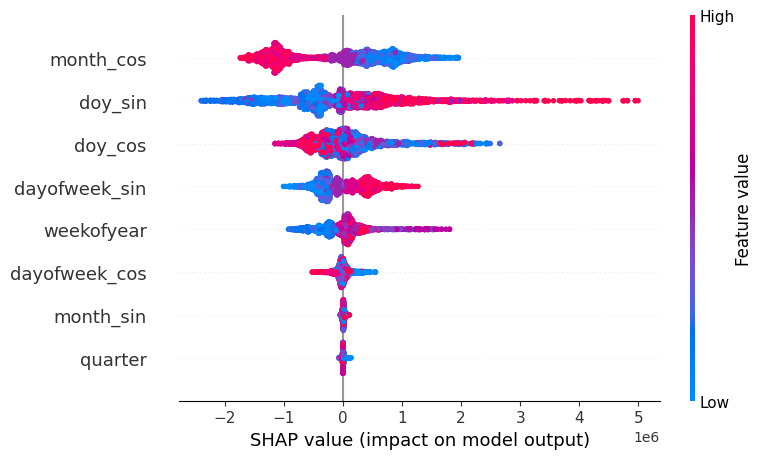

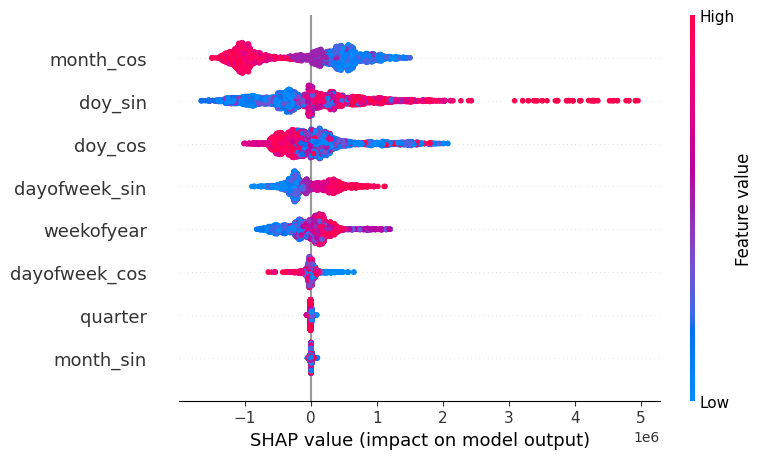

         Date       Revenue          COGS
0  2023-01-01  6.035801e+06  4.623406e+06
1  2023-01-02  3.666818e+06  3.331642e+06
2  2023-01-03  2.986876e+06  2.447669e+06
3  2023-01-04  2.414041e+06  1.867725e+06
4  2023-01-05  2.434304e+06  1.997523e+06
5  2023-01-06  2.397225e+06  1.918374e+06
6  2023-01-07  2.486515e+06  1.975350e+06
7  2023-01-08  2.496094e+06  1.964177e+06
8  2023-01-09  2.725009e+06  2.194908e+06
9  2023-01-10  2.617197e+06  2.143140e+06
Submission shape: (548, 3)


In [ ]:

chosen_rev_model  = best_rev_models['RF']
chosen_cogs_model = best_cogs_models['RF']

# SHAP
rev_explainer  = shap.TreeExplainer(chosen_rev_model)
cogs_explainer = shap.TreeExplainer(chosen_cogs_model)
shap.summary_plot(rev_explainer.shap_values(X),  X, feature_names=features)
shap.summary_plot(cogs_explainer.shap_values(X), X, feature_names=features)

# Submission
submission = pd.read_csv('/content/drive/MyDrive/Datathon/Analytical/sample_submission.csv')
submission['Date'] = pd.to_datetime(submission['Date'])
submission = add_features(submission)
X_submit = submission[features].to_numpy()

submission['Revenue'] = chosen_rev_model.predict(X_submit).clip(min=0)
submission['COGS']    = chosen_cogs_model.predict(X_submit).clip(min=0)

submission = submission[['Date', 'Revenue', 'COGS']]
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('/content/drive/MyDrive/submission.csv', index=False)
print(submission.head(10))
print(f'Submission shape: {submission.shape}')